In [5]:
import pandas as pd
url_drive='https://drive.google.com/file/d/1zMWmL7A-VH3_wPYgCiUH6bMbd39EPrcQ/view?usp=sharing'
file_id = url_drive.split('/d/')[1].split('/')[0]
url_descarga = f"https://drive.google.com/uc?export=download&id={file_id}"
df=pd.read_csv(url_descarga)
print('Archivo leido correctamente')
display(df.head())
df.shape

Archivo leido correctamente


,texto_completo,categoria
0,React 18: Hydration failed because the initial...,Frontend
1,Why does Visual Studio Code give me an error w...,Frontend
2,"""A listener indicated an asynchronous response...",Frontend
3,Deprecation notice: ReactDOM.render is no long...,Frontend
4,"Message ""npm WARN config global `--global`, `-...",Frontend


(30000, 2)

In [8]:
import re
def str_a_limpio(texto):
    # PARA QUE PROCESEMOS MEJOR LOS DATOS: pasamos a minúsculas, quitamos etiquetas HTML, links, saltos de línea, signos, números y espacios de más
    texto = str(texto).lower()
    texto = re.sub(r'<[^>]+>', ' ', texto)
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)
    texto = re.sub(r'[\r\n\t]+', ' ', texto)
    texto = re.sub(r'[^a-záéíóúñ\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

print('En esta sección se quitan etiquetas HTML y símbolos o caracteres especiales')
df['texto_limpio'] = df['texto_completo'].apply(str_a_limpio)

print('TEXTO LIMPIO')
print('-'*20)
print(df['texto_limpio'].head())


En esta sección se quitan etiquetas HTML y símbolos o caracteres especiales
TEXTO LIMPIO
--------------------
0    react hydration failed because the initial ui ...
1    why does visual studio code give me an error w...
2    a listener indicated an asynchronous response ...
3    deprecation notice reactdom render is no longe...
4    message npm warn config global global local ar...
Name: texto_limpio, dtype: object


In [7]:
display(df.head())
df.shape

,texto_completo,categoria,texto_limpio
0,React 18: Hydration failed because the initial...,Frontend,react hydration failed because the initial ui ...
1,Why does Visual Studio Code give me an error w...,Frontend,why does visual studio code give me an error w...
2,"""A listener indicated an asynchronous response...",Frontend,a listener indicated an asynchronous response ...
3,Deprecation notice: ReactDOM.render is no long...,Frontend,deprecation notice reactdom render is no longe...
4,"Message ""npm WARN config global `--global`, `-...",Frontend,message npm warn config global global local ar...


(30000, 3)

In [9]:
from numpy import printoptions
df=df.drop(columns=['texto_completo'])
print('columna con HTML borrada')
df=df[['texto_limpio','categoria']]
print('\n DB FINAL  ELIMINANDO COLUMNA CON ETIQUETAS HTML Y CARACTERES ESPECIALES')
print('-'*30)

display(df.head())
print('\n Dimensiones del CSV', df.shape)

df.to_csv('BD_STACKOVERFLOW_INGLES.csv', index=False)
print('ARCHIVO GUARDADO  COMO  : BD_STACKOVERFLOW_INGLES.csv')

columna con HTML borrada

 DB FINAL  ELIMINANDO COLUMNA CON ETIQUETAS HTML Y CARACTERES ESPECIALES
------------------------------


,texto_limpio,categoria
0,react hydration failed because the initial ui ...,Frontend
1,why does visual studio code give me an error w...,Frontend
2,a listener indicated an asynchronous response ...,Frontend
3,deprecation notice reactdom render is no longe...,Frontend
4,message npm warn config global global local ar...,Frontend



 Dimensiones del CSV (30000, 2)
ARCHIVO GUARDADO  COMO  : BD_STACKOVERFLOW_INGLES.csv


Explorando dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   texto_limpio  30000 non-null  object
 1   categoria     30000 non-null  object
dtypes: object(2)
memory usage: 468.9+ KB
None

 VALORES NULOS
texto_limpio    0
categoria       0
dtype: int64


/tmp/ipykernel_887/1350000898.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='categoria', palette='viridis')


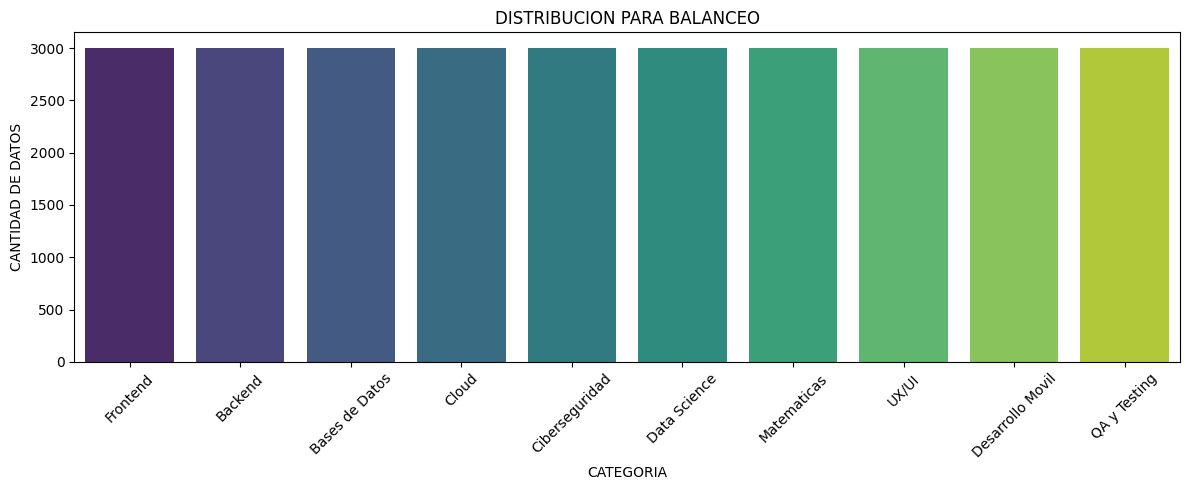

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
#EMEPZAMOS POR LA EXPLORACION DEL ARCHIVO  DF  PARA VERIFICAR QUE NO HAY VALORES NULOS Y CONOCER NUESTRO BASE DE DATOS CON LA QUE SE TRABAJARA

print('Explorando dataset')
print(df.info())
print('\n VALORES NULOS')
print(df.isnull().sum())
#  GRAFICO PARA  QUE VERIFIQUEMOS SI SON CLASES DESBALANCEADAS, EN CASO DE QUE LO SEAN , EN ESTE EJMEPLO NO, PODRIAMOS USAR METODOS DE BALANECO PARA UN MEJOR TRATADO DE LOS DATOS

plt.figure(figsize=(12,5))
sns.countplot(data=df, x='categoria', palette='viridis')
plt.title('DISTRIBUCION PARA BALANCEO')
plt.xlabel('CATEGORIA')
plt.ylabel('CANTIDAD DE DATOS')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


palabras por texto
count    30000.000000
mean       263.161300
std        313.477276
min         13.000000
25%        106.000000
50%        176.000000
75%        296.000000
max       4653.000000
Name: contador_palabras, dtype: float64


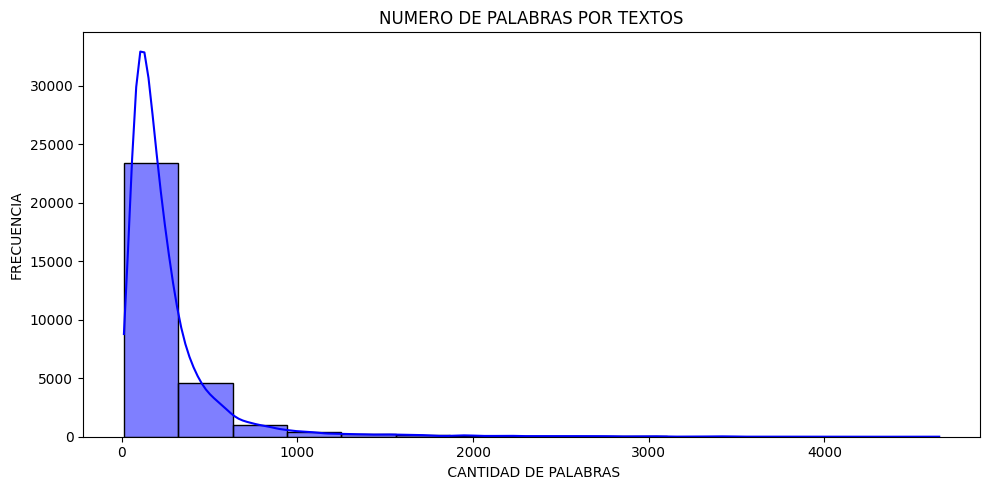

In [11]:
#TAMBIEN PODEMOS VERIFICAR LA LONGITUD DE LOS TEXTOS PARA  UN ANALISIS POSTERIOR
df['contador_palabras']= df['texto_limpio'].apply(lambda x: len(str(x).split()))
print('palabras por texto')
print(df['contador_palabras'].describe())

#vamos a hacer su grafico

plt.figure(figsize=(10,5))
sns.histplot(df['contador_palabras'], bins=15, kde=True, color='blue')
plt.title('NUMERO DE PALABRAS POR TEXTOS')
plt.xlabel(' CANTIDAD DE PALABRAS')
plt.ylabel('FRECUENCIA')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#Separar los textos y  categorías
X = df['texto_limpio']
y = df['categoria']
#division de  80% para entrenar y 20% para evaluacion
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#El texto a números (TF-IDF)
vectorizador = TfidfVectorizer(max_features=1500, stop_words='english')
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

#PRIMER MODELO: Regresión Logística
print("Entrenando Regresión Logística...")
modelo_lr = LogisticRegression(random_state=42, max_iter=500)
modelo_lr.fit(X_train_vec, y_train)
y_pred_lr = modelo_lr.predict(X_test_vec)
precision_lr = accuracy_score(y_test, y_pred_lr)

print(f"\n¡Listo! Precisión de la Regresión Logística: {precision_lr * 100:.2f}%\n")
print("Reporte de Clasificación")
print(classification_report(y_test, y_pred_lr))

Entrenando Regresión Logística...

¡Listo! Precisión de la Regresión Logística: 78.98%

Reporte de Clasificación
                  precision    recall  f1-score   support

         Backend       0.68      0.65      0.67       612
  Bases de Datos       0.79      0.84      0.82       609
  Ciberseguridad       0.76      0.72      0.74       625
           Cloud       0.82      0.81      0.81       635
    Data Science       0.93      0.90      0.92       591
Desarrollo Movil       0.81      0.79      0.80       618
        Frontend       0.60      0.66      0.63       567
     Matematicas       0.86      0.90      0.88       576
    QA y Testing       0.88      0.85      0.87       572
           UX/UI       0.78      0.77      0.77       595

        accuracy                           0.79      6000
       macro avg       0.79      0.79      0.79      6000
    weighted avg       0.79      0.79      0.79      6000



In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import classification_report

#Cargar y separar los datos (30,000 registros)
X = df['texto_limpio']
y = df['categoria']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#TF-IDF con N-gramas (Optimizado)
vectorizador = TfidfVectorizer(max_features=2500, ngram_range=(1, 2))
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)
print("Configurando arquitecturas optimizadas...")
# Regresión Logística
modelo_lr = LogisticRegression(
    C=1.0, class_weight='balanced', random_state=42, max_iter=1000, n_jobs=-1
)
# SVM Lineal + Calibración para soft voting
svm_rapido = LinearSVC(C=1.0, class_weight='balanced', random_state=42)
modelo_svm = CalibratedClassifierCV(svm_rapido, cv=3)
# Random Forest (100 árboles con n_jobs=-1 para paralelizar en todos los núcleos)
modelo_rf = RandomForestClassifier(
    n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1
)

#Validación Cruzada en paralelo (n_jobs=-1 acelera)
print("\nRealizando Validación Cruzada (3-Folds rápidos en paralelo)...")
cv_lr = cross_val_score(modelo_lr, X_train_vec, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
cv_svm = cross_val_score(modelo_svm, X_train_vec, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
cv_rf = cross_val_score(modelo_rf, X_train_vec, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()
print(f"Precisión promedio LR:  {cv_lr*100:.2f}%")
print(f"Precisión promedio SVM: {cv_svm*100:.2f}%")
print(f"Precisión promedio RF:  {cv_rf*100:.2f}%")

#Construir el Voting Classifier con Pesos
ensamble = VotingClassifier(
    estimators=[('lr', modelo_lr), ('svm', modelo_svm), ('rf', modelo_rf)],
    voting='soft',
    weights=[1.5, 2.0, 1.0],
    n_jobs=-1  # Entrena los 3 modelos simultáneamente
)
# Entrenamiento final y Evaluación
print("\nEntrenando el Ensamble final...")
ensamble.fit(X_train_vec, y_train)
y_pred = ensamble.predict(X_test_vec)

print("\n--- REPORTE DE CLASIFICACIÓN FINAL ---")
print(classification_report(y_test, y_pred))

Configurando arquitecturas optimizadas...

Realizando Validación Cruzada (3-Folds rápidos en paralelo)...
Precisión promedio LR:  79.23%
Precisión promedio SVM: 78.99%
Precisión promedio RF:  74.17%

Entrenando el Ensamble final...

--- REPORTE DE CLASIFICACIÓN FINAL ---
                  precision    recall  f1-score   support

         Backend       0.68      0.65      0.67       600
  Bases de Datos       0.78      0.82      0.80       600
  Ciberseguridad       0.79      0.76      0.77       600
           Cloud       0.82      0.81      0.81       600
    Data Science       0.92      0.93      0.93       600
Desarrollo Movil       0.81      0.84      0.83       600
        Frontend       0.67      0.69      0.68       600
     Matematicas       0.88      0.90      0.89       600
    QA y Testing       0.89      0.89      0.89       600
           UX/UI       0.80      0.77      0.78       600

        accuracy                           0.80      6000
       macro avg       0.80   

In [14]:
import joblib

# Guardamos el diccionario de palabras y el cerebro del modelo
joblib.dump(vectorizador, 'vectorizador_tfidf_30k.pkl')
joblib.dump(ensamble, 'modelo_ensamble_30k.pkl')

print("¡Archivos .pkl exportados con éxito!")

¡Archivos .pkl exportados con éxito!


In [15]:
#PRUEBA DEL MODELO

#preguntas de prueba
duda_usuario = "I am writing a complex SQL query with multiple JOINs in PostgreSQL, but my window function is returning duplicate rows and slowing down the database."

#Vectorizamos el texto con el mismo TfidfVectorizer del entrenamiento
duda_vectorizada = vectorizador.transform([duda_usuario])

# predecimos la categoría y sus probabilidades
prediccion = ensamble.predict(duda_vectorizada)[0]
probabilidades = ensamble.predict_proba(duda_vectorizada)[0]

# Obtenemos el porcentaje de seguridad del modelo para la categoría ganadora
idx_ganador = list(ensamble.classes_).index(prediccion)
seguridad = probabilidades[idx_ganador] * 100

#resultados
print("=" * 70)
print(f"TEXTO ANALIZADO:\n'{duda_usuario}'")
print("-" * 70)
print(f"CATEGORÍA PREDICHA : -->  {prediccion.upper()}  <--")
print(f"NIVEL DE SEGURIDAD : {seguridad:.2f}%")
print("=" * 70)

TEXTO ANALIZADO:
'I am writing a complex SQL query with multiple JOINs in PostgreSQL, but my window function is returning duplicate rows and slowing down the database.'
----------------------------------------------------------------------
CATEGORÍA PREDICHA : -->  BASES DE DATOS  <--
NIVEL DE SEGURIDAD : 84.31%
